In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

In [2]:
df = pd.read_csv("../data/processed1/final_selection.csv")

In [3]:
print(df.head())

              datetime  consumption  Heating_Cooking  Communication_IT  \
0  2023-12-16 00:00:00        2.582              3.0               1.0   
1  2023-12-16 06:00:00        2.519              3.0               1.0   
2  2023-12-16 12:00:00        2.456              3.0               1.0   
3  2023-12-16 18:00:00        2.393              3.0               1.0   
4  2023-12-17 00:00:00        2.480              3.0               1.0   

   Mobility_Energy  Cooling_Refrigeration  Cleaning_Household  \
0              0.0                    2.0                 1.0   
1              0.0                    2.0                 1.0   
2              0.0                    2.0                 1.0   
3              0.0                    2.0                 1.0   
4              0.0                    2.0                 1.0   

   Security_Infrastructure  Entertainment_ICT  Other  ...  is_weekend  \
0                      0.0                3.0    0.0  ...           1   
1                 

In [4]:
df = df.sort_values('datetime').reset_index(drop=True)

In [5]:
target = 'consumption'

features = [
    'branch_encoded',
    'sub_type_encoded',
    'hour',
    'day_of_week',
    'day',
    'month',
    'is_weekend',
    'hour_sin',
    'hour_cos',
    'lag_1',
    'lag_4',
    'lag_28',
    'rolling_mean_4',
    'rolling_mean_28',
    'rolling_std_4',
    'household_id_encoded'
]

In [6]:
def smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

In [7]:
def run_time_series_cv(model, df, features, target, n_splits=5):
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    results = []
    predictions = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):

        train = df.iloc[train_idx]
        test = df.iloc[test_idx]

        X_train = train[features]
        y_train = train[target]

        X_test = test[features]
        y_test = test[target]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # metrics
        results.append(evaluate(y_test, preds))

        # store predictions
        fold_df = test.copy()
        fold_df["actual"] = y_test.values
        fold_df["predicted"] = preds
        fold_df["fold"] = fold + 1

        predictions.append(fold_df)
        
        if fold == n_splits - 1:
            last_model = model
            X_test_last = X_test.copy()

    return results, pd.concat(predictions, ignore_index=True), last_model, X_test_last

In [97]:
# pip install xgboost lightgbm catboost

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


In [11]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
)

In [10]:
xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=5,
    random_state=42
)

In [14]:
lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=15,
    random_state=42
)


In [ ]:
cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=15,
    verbose=0,
    random_seed=42
)

Random Forest

In [16]:
rf_results, rf_predictions, rf_last_model, rf_last_test = run_time_series_cv(
   rf, df, features, target)

XGBoost

In [17]:
xgb_results, xgb_predictions, xgb_last_model, xgb_last_test = run_time_series_cv(
    xgb, df, features, target
)

LightGBM

In [18]:
lgbm_results, lgbm_predictions, lgbm_last_model, lgbm_last_test = run_time_series_cv(
    lgbm, df, features, target
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1853
[LightGBM] [Info] Number of data points in the train set: 190164, number of used features: 16
[LightGBM] [Info] Start training from score 21.766158
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009308 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1855
[LightGBM] [Info] Number of data points in the train set: 380326, number of used features: 16
[LightGBM] [Info] Start training from score 25.387295
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013795 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

CatBoost

In [19]:
cat_results, cat_predictions, cat_last_model, cat_last_test = run_time_series_cv(
    cat, df, features, target
)

In [20]:
def summarize(results, name):
    df_res = pd.DataFrame(results)
    df_res["model"] = name
    return df_res

all_results = pd.concat([
    summarize(rf_results, "Random Forest"),
    summarize(xgb_results, "XGBoost"),
    summarize(lgbm_results, "LightGBM"),
    summarize(cat_results, "CatBoost")
])

all_results

,MSE,RMSE,MAE,sMAPE,R2,model
0,122908.655378,350.583307,17.514899,31.758433,0.608800,Random Forest
1,106919.169530,326.984968,17.190382,33.070879,0.696617,Random Forest
2,152439.356548,390.434830,21.138467,34.535348,0.752420,Random Forest
3,80073.324808,282.972304,12.191914,28.681723,0.868851,Random Forest
4,153924.057744,392.331566,19.692927,26.731322,0.870324,Random Forest
0,141189.680878,375.752154,22.127096,49.230943,0.550615,XGBoost
1,126700.985401,355.950819,21.014403,49.592673,0.640486,XGBoost
2,215064.365167,463.750326,24.835223,45.868487,0.650710,XGBoost
3,133421.259426,365.268750,19.426234,41.024946,0.781475,XGBoost
4,220309.257940,469.371130,25.792657,37.146280,0.814397,XGBoost


In [21]:
def to_df(results, model_name):
    df_res = pd.DataFrame(results)
    df_res["model"] = model_name
    df_res["fold"] = range(1, len(df_res) + 1)
    return df_res

rf_df = to_df(rf_results, "Random Forest")
xgb_df = to_df(xgb_results, "XGBoost")
lgbm_df = to_df(lgbm_results, "LightGBM")
cat_df = to_df(cat_results, "CatBoost")

all_df = pd.concat([rf_df, xgb_df, lgbm_df, cat_df])

In [22]:
rmse_pivot = all_df.pivot(index="fold", columns="model", values="RMSE")
rmse_pivot

model,CatBoost,LightGBM,Random Forest,XGBoost
fold,,,,
1,492.410640,373.416061,350.583307,375.752154
2,453.542216,359.273490,326.984968,355.950819
3,539.371454,438.983785,390.434830,463.750326
4,450.246885,341.614618,282.972304,365.268750
5,560.019424,455.242607,392.331566,469.371130


In [23]:
mse_pivot = all_df.pivot(index="fold", columns="model", values="MSE")
mse_pivot

model,CatBoost,LightGBM,Random Forest,XGBoost
fold,,,,
1,242468.238870,139439.554919,122908.655378,141189.680878
2,205700.541938,129077.440532,106919.169530,126700.985401
3,290921.564870,192706.763518,152439.356548,215064.365167
4,202722.257792,116700.547092,80073.324808,133421.259426
5,313621.755124,207245.831075,153924.057744,220309.257940


In [24]:
mae_pivot = all_df.pivot(index="fold", columns="model", values="MAE")
mae_pivot

model,CatBoost,LightGBM,Random Forest,XGBoost
fold,,,,
1,26.510666,23.044757,17.514899,22.127096
2,25.588073,27.084791,17.190382,21.014403
3,27.240232,22.859319,21.138467,24.835223
4,24.092292,18.350338,12.191914,19.426234
5,29.939936,25.156049,19.692927,25.792657


In [25]:
smape_pivot = all_df.pivot(index="fold", columns="model", values="sMAPE")
smape_pivot

model,CatBoost,LightGBM,Random Forest,XGBoost
fold,,,,
1,97.511005,68.475554,31.758433,49.230943
2,72.459230,60.542107,33.070879,49.592673
3,73.087803,49.943688,34.535348,45.868487
4,61.326460,47.334345,28.681723,41.024946
5,60.792267,44.993941,26.731322,37.146280


In [26]:
r2_pivot = all_df.pivot(index="fold", columns="model", values="R2")
r2_pivot

model,CatBoost,LightGBM,Random Forest,XGBoost
fold,,,,
1,0.228260,0.556185,0.608800,0.550615
2,0.416325,0.633743,0.696617,0.640486
3,0.527508,0.687021,0.752420,0.650710
4,0.667970,0.808861,0.868851,0.781475
5,0.735784,0.825402,0.870324,0.814397


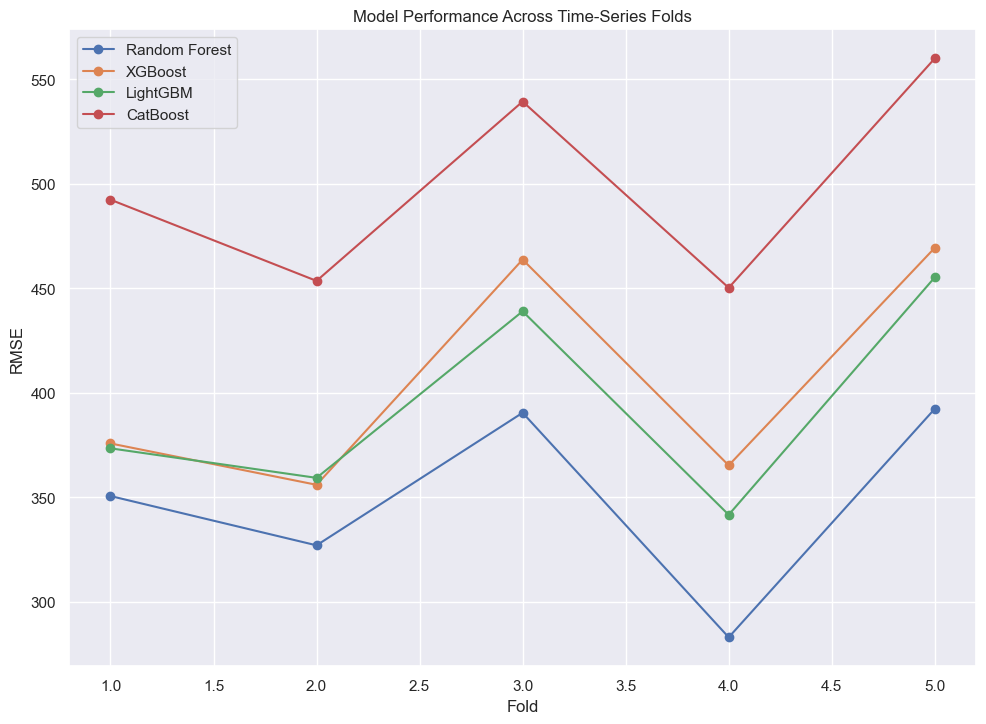

In [27]:
for model in all_df["model"].unique():
    subset = all_df[all_df["model"] == model]
    plt.plot(subset["fold"], subset["RMSE"], marker='o', label=model)

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("Model Performance Across Time-Series Folds")
plt.legend()
plt.show()

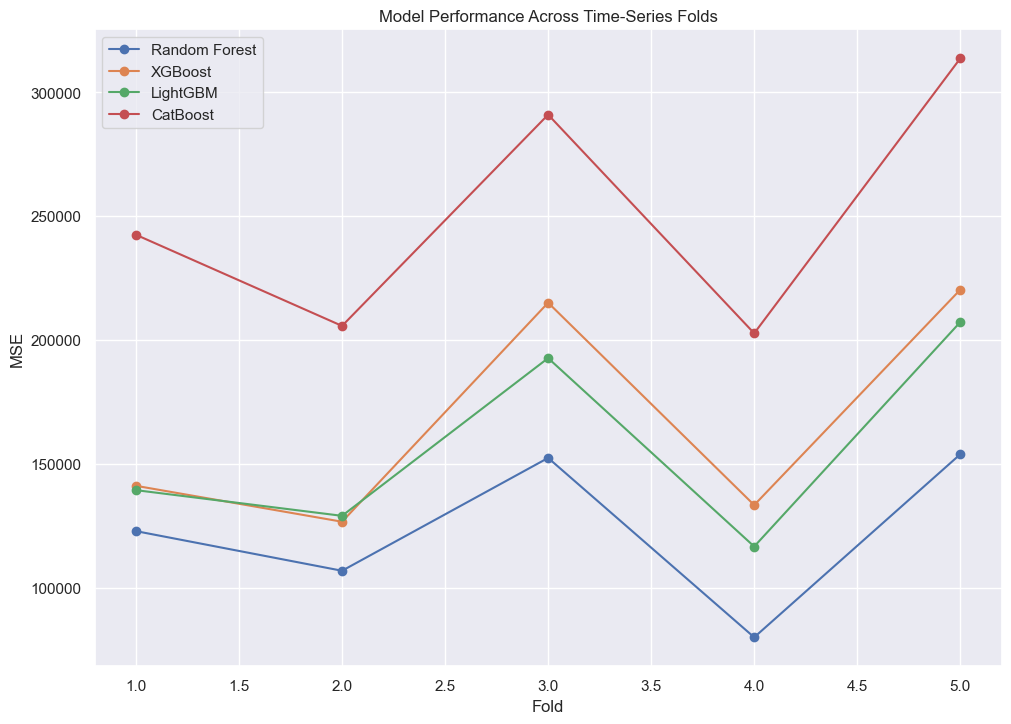

In [28]:
for model in all_df["model"].unique():
    subset = all_df[all_df["model"] == model]
    plt.plot(subset["fold"], subset["MSE"], marker='o', label=model)

plt.xlabel("Fold")
plt.ylabel("MSE")
plt.title("Model Performance Across Time-Series Folds")
plt.legend()
plt.show()

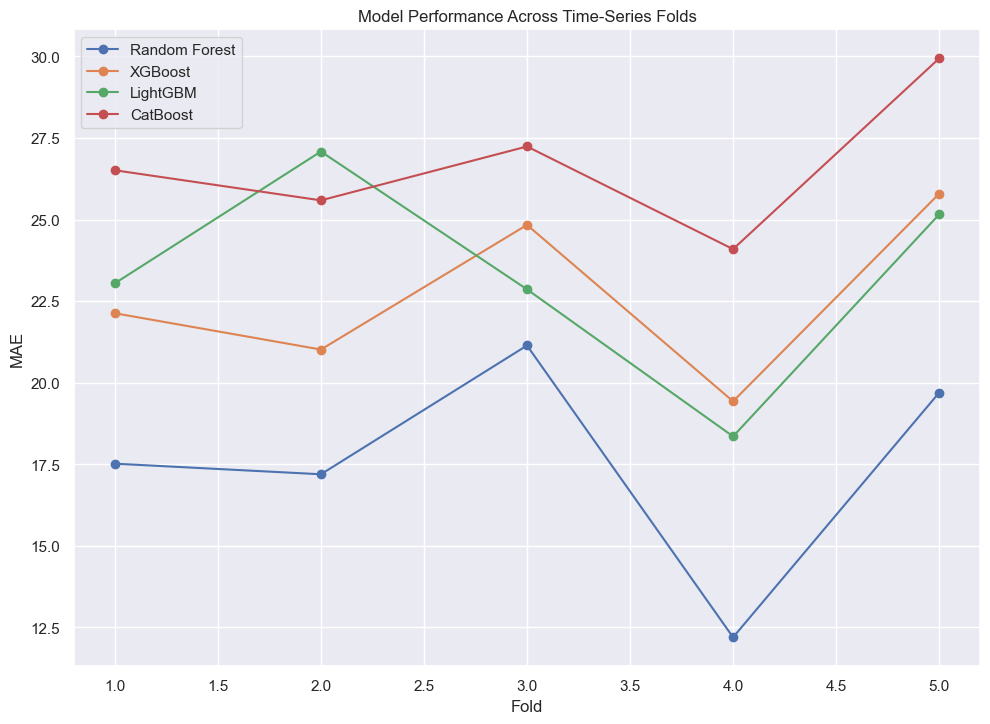

In [29]:
for model in all_df["model"].unique():
    subset = all_df[all_df["model"] == model]
    plt.plot(subset["fold"], subset["MAE"], marker='o', label=model)

plt.xlabel("Fold")
plt.ylabel("MAE")
plt.title("Model Performance Across Time-Series Folds")
plt.legend()
plt.show()

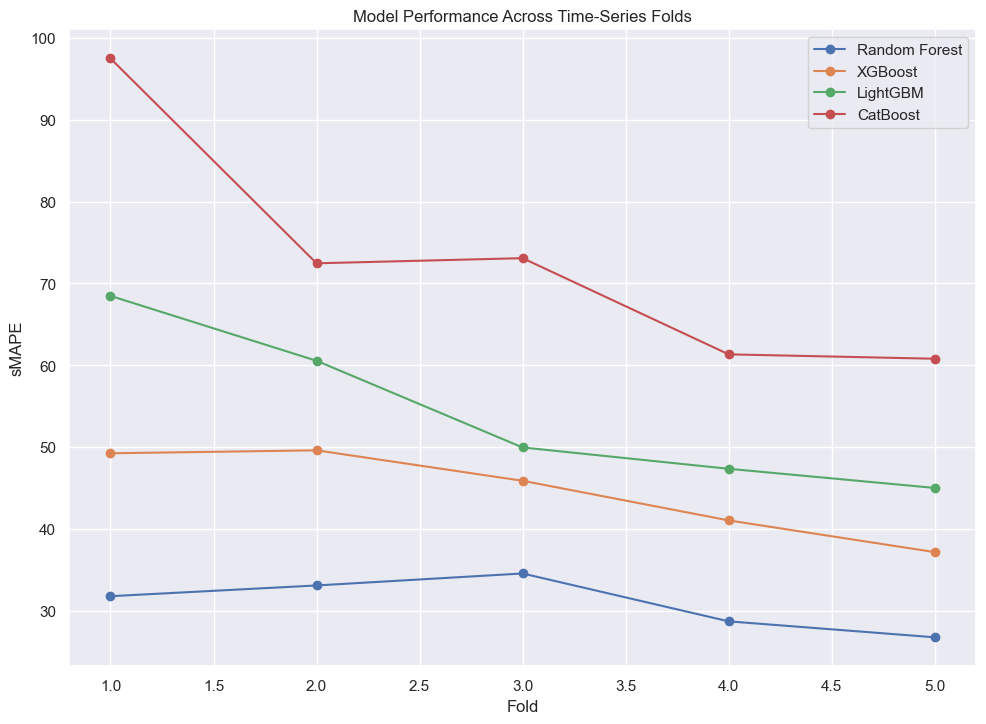

In [30]:
for model in all_df["model"].unique():
    subset = all_df[all_df["model"] == model]
    plt.plot(subset["fold"], subset["sMAPE"], marker='o', label=model)

plt.xlabel("Fold")
plt.ylabel("sMAPE")
plt.title("Model Performance Across Time-Series Folds")
plt.legend()
plt.show()

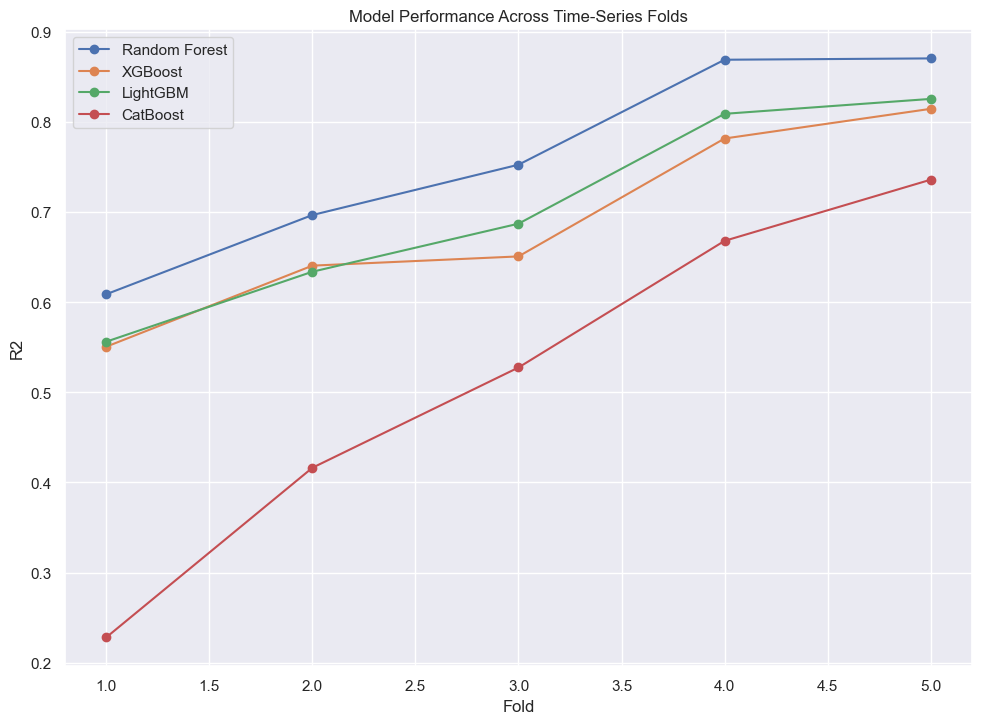

In [31]:
for model in all_df["model"].unique():
    subset = all_df[all_df["model"] == model]
    plt.plot(subset["fold"], subset["R2"], marker='o', label=model)

plt.xlabel("Fold")
plt.ylabel("R2")
plt.title("Model Performance Across Time-Series Folds")
plt.legend()
plt.show()

In [32]:
rf_df = pd.DataFrame(rf_results)
xgb_df = pd.DataFrame(xgb_results)
lgbm_df = pd.DataFrame(lgbm_results)
cat_df = pd.DataFrame(cat_results)

In [33]:
rf_mean = rf_df.mean()
xgb_mean = xgb_df.mean()
lgbm_mean = lgbm_df.mean()
cat_mean = cat_df.mean()

In [34]:
leaderboard = pd.DataFrame({
    "Random Forest": rf_mean,
    "XGBoost": xgb_mean,
    "LightGBM": lgbm_mean,
    "CatBoost": cat_mean
}).T

In [35]:
leaderboard["Score"] = (
    leaderboard["RMSE"].rank(ascending=True) +
    leaderboard["MAE"].rank(ascending=True) +
    leaderboard["sMAPE"].rank(ascending=True) +
    leaderboard["R2"].rank(ascending=False)
)

In [38]:
leaderboard = leaderboard.sort_values("Score")
leaderboard.T

,Random Forest,XGBoost,LightGBM,CatBoost
MSE,123252.912802,167337.109762,157034.027427,251086.871719
RMSE,348.661395,406.018636,393.706112,499.118124
MAE,17.545718,22.639123,23.299051,26.674240
sMAPE,30.955541,44.572666,54.257927,73.035353
R2,0.759403,0.687536,0.702243,0.515170
Score,4.000000,10.000000,10.000000,16.000000
Weighted Score,1.000000,2.500000,2.500000,4.000000


In [37]:
leaderboard["Weighted Score"] = (
    0.4 * leaderboard["RMSE"].rank(ascending=True) +
    0.3 * leaderboard["MAE"].rank(ascending=True) +
    0.2 * leaderboard["sMAPE"].rank(ascending=True) +
    0.1 * leaderboard["R2"].rank(ascending=False)
)

In [39]:
leaderboard = leaderboard.sort_values("Weighted Score")
print(leaderboard)

                         MSE        RMSE        MAE      sMAPE        R2  \
Random Forest  123252.912802  348.661395  17.545718  30.955541  0.759403   
XGBoost        167337.109762  406.018636  22.639123  44.572666  0.687536   
LightGBM       157034.027427  393.706112  23.299051  54.257927  0.702243   
CatBoost       251086.871719  499.118124  26.674240  73.035353  0.515170   

               Score  Weighted Score  
Random Forest    4.0             1.0  
XGBoost         10.0             2.5  
LightGBM        10.0             2.5  
CatBoost        16.0             4.0  


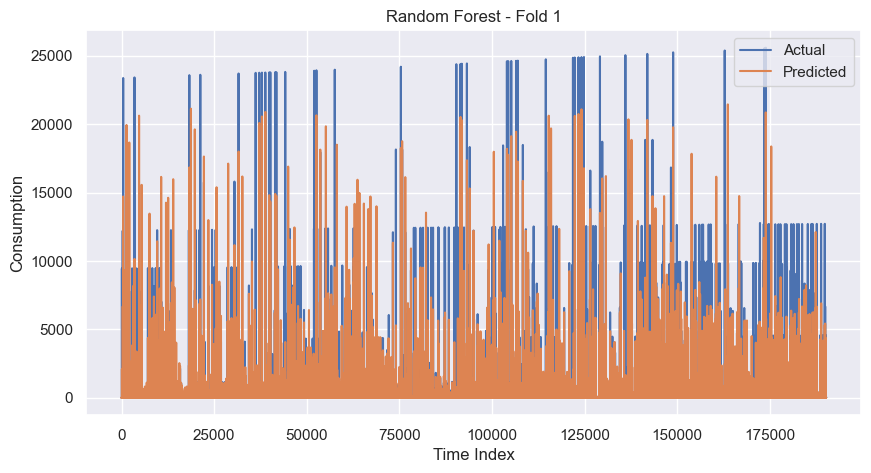

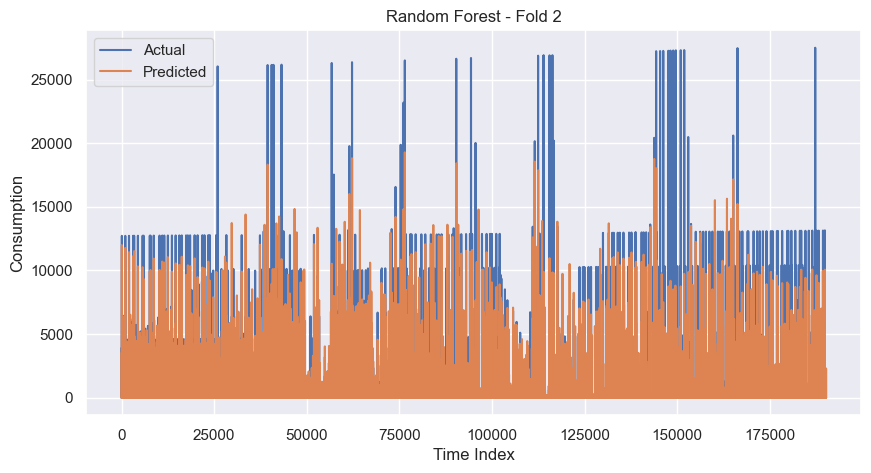

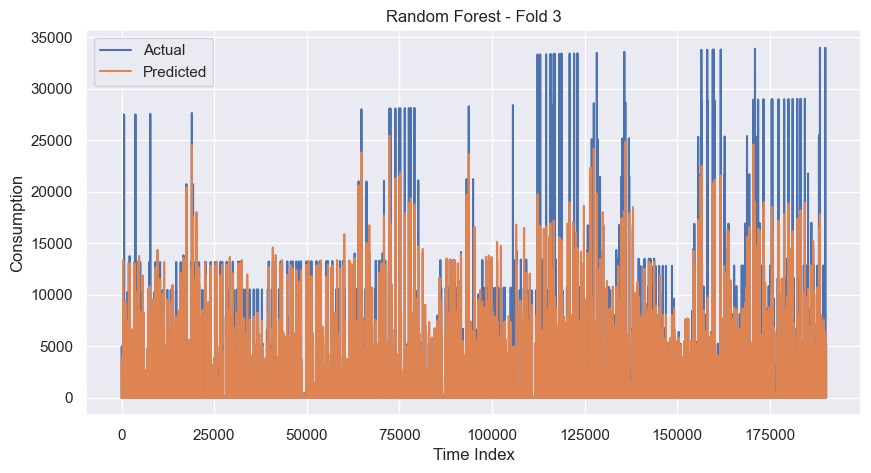

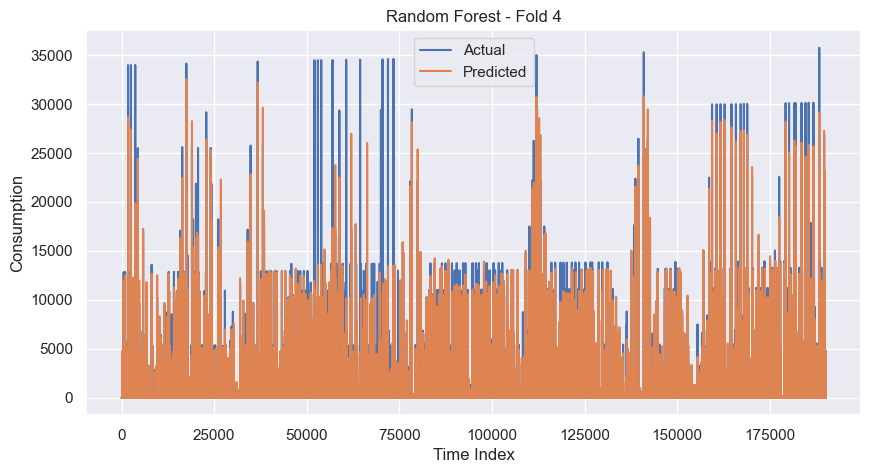

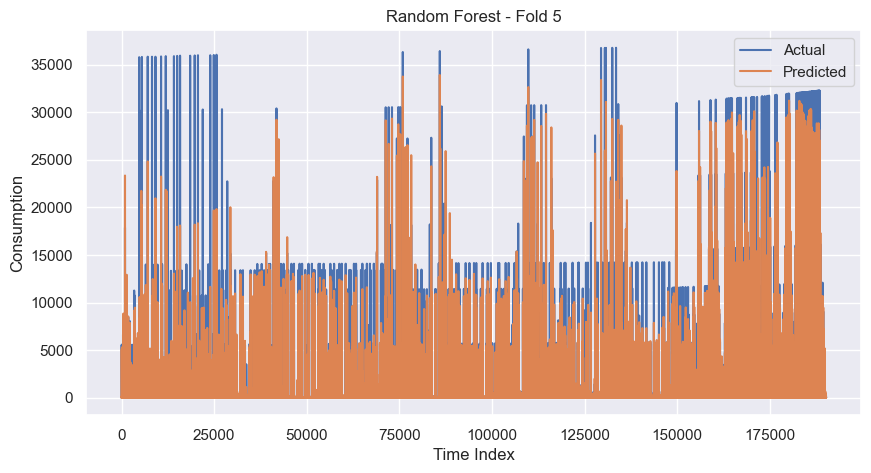

In [40]:
for fold in sorted(rf_predictions["fold"].unique()):
    
    subset = rf_predictions[rf_predictions["fold"] == fold]
    
    plt.figure(figsize=(10,5))
    
    plt.plot(subset["actual"].values, label="Actual")
    plt.plot(subset["predicted"].values, label="Predicted")
    
    plt.title(f"Random Forest - Fold {fold}")
    plt.xlabel("Time Index")
    plt.ylabel("Consumption")
    plt.legend()
    
    plt.show()

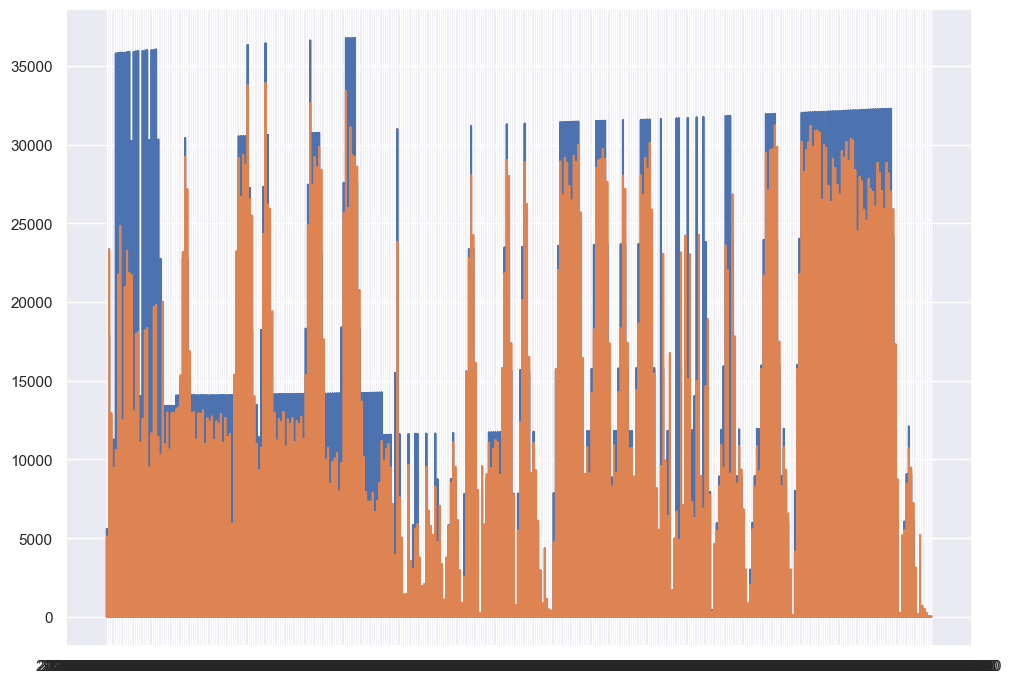

In [41]:

subset = subset.sort_values("datetime")

plt.plot(subset["datetime"], subset["actual"], label="Actual")
plt.plot(subset["datetime"], subset["predicted"], label="Predicted")

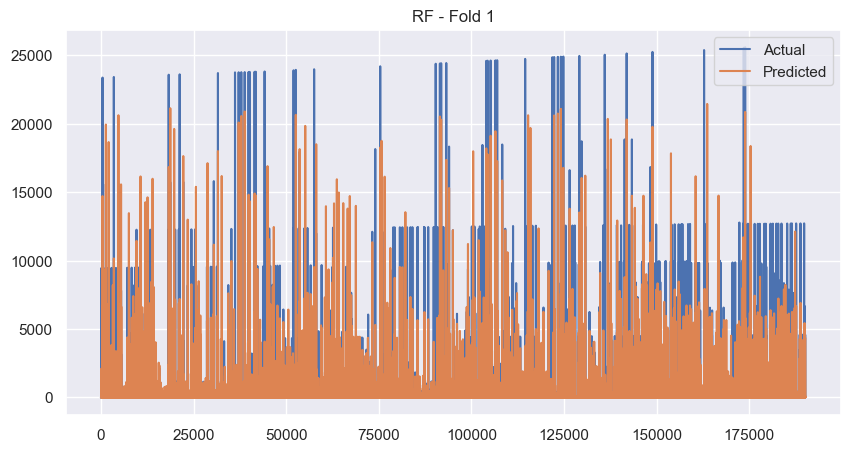

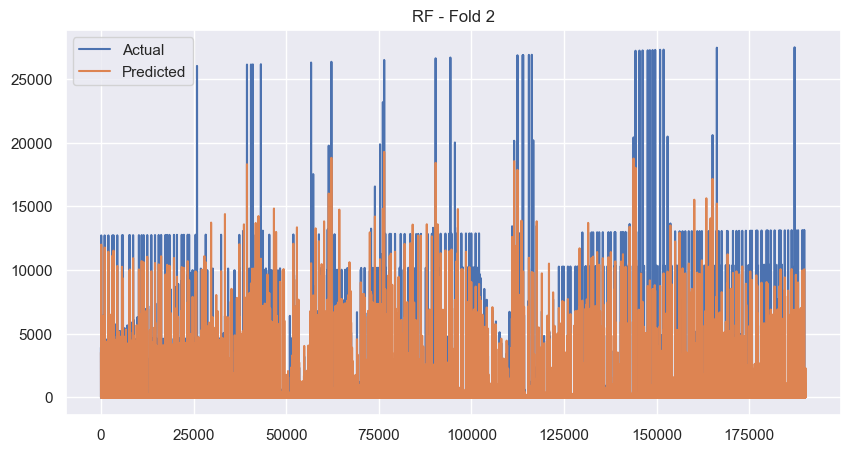

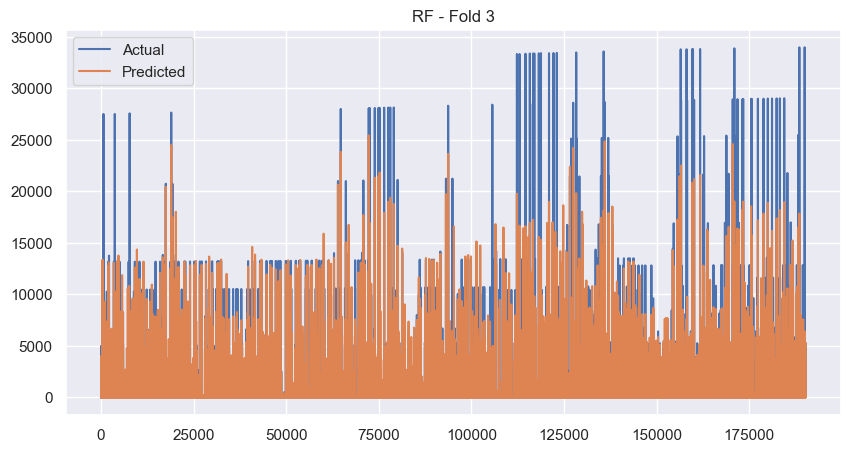

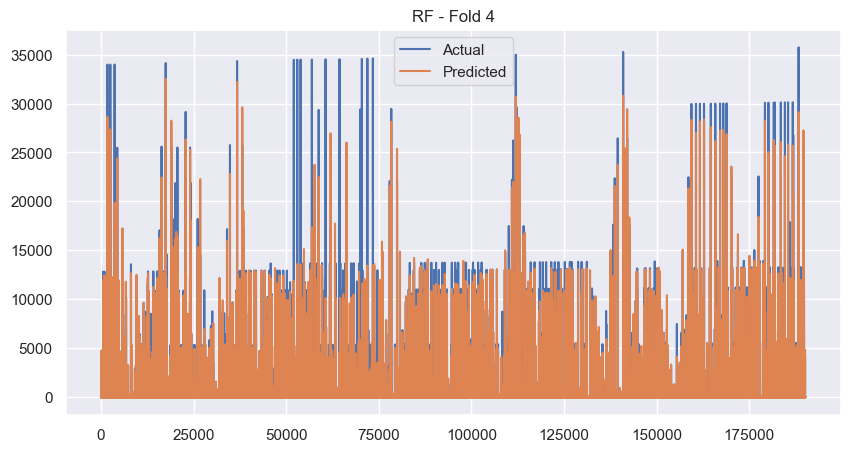

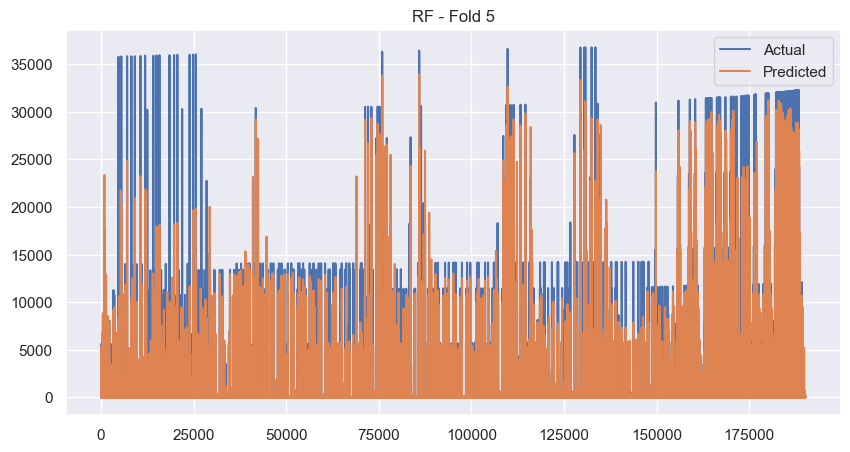

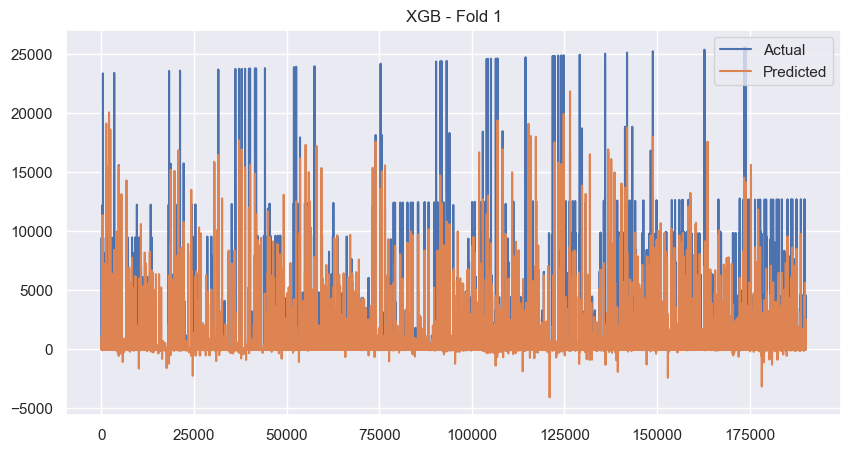

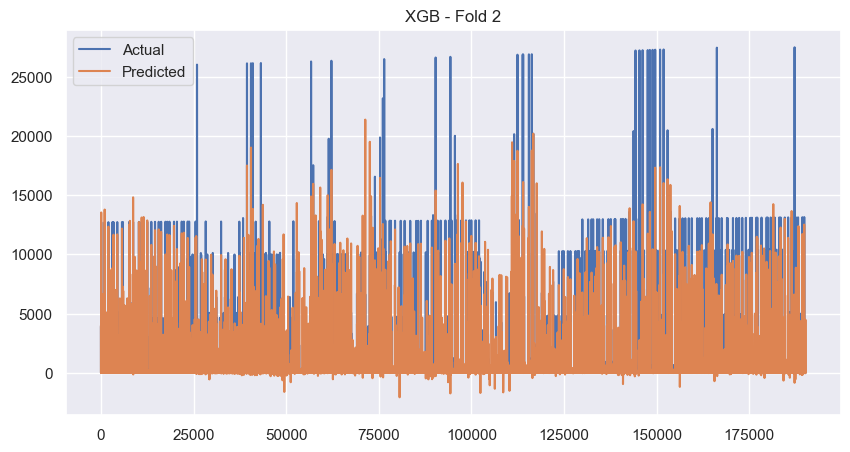

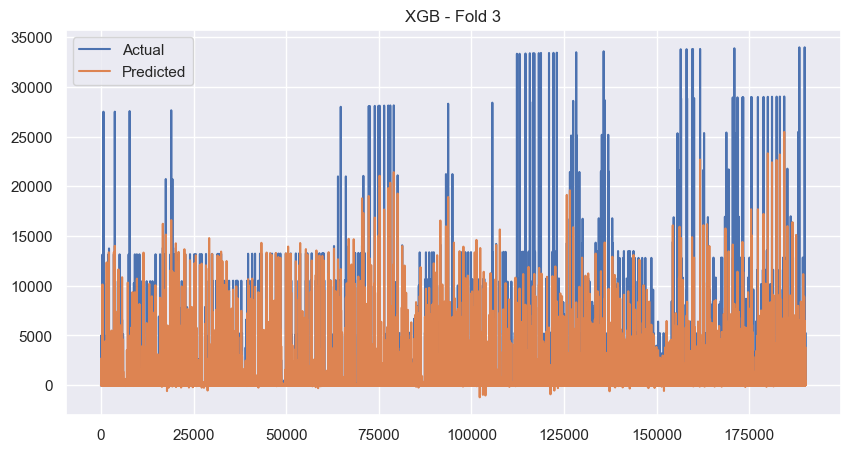

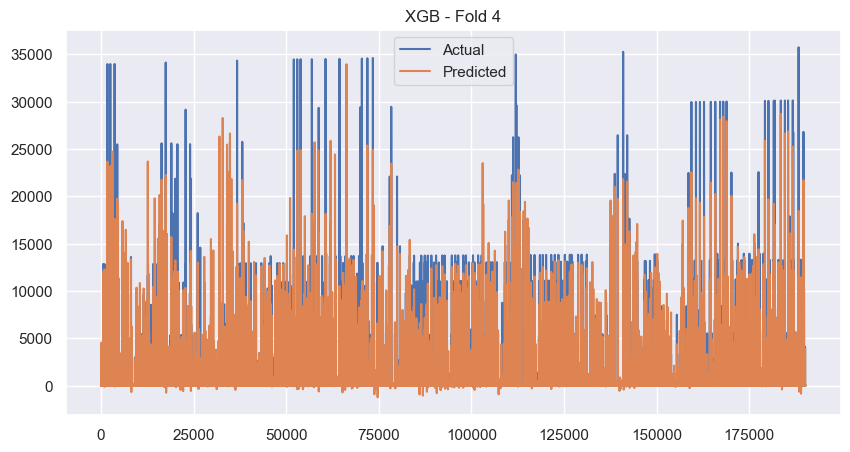

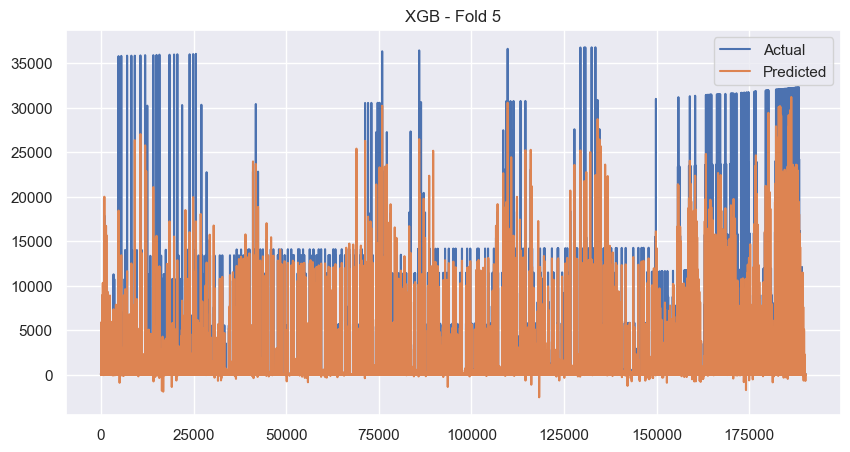

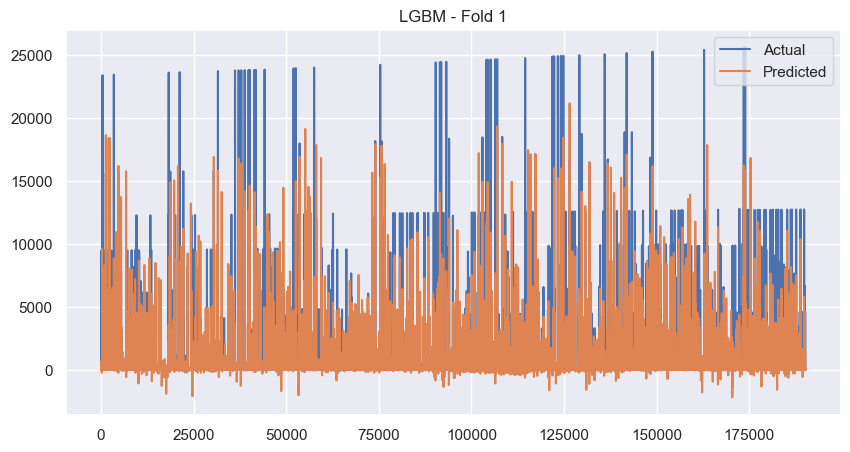

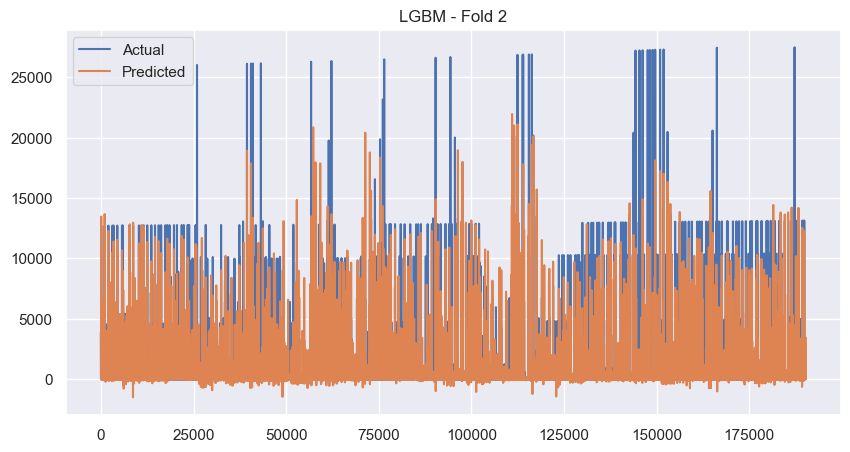

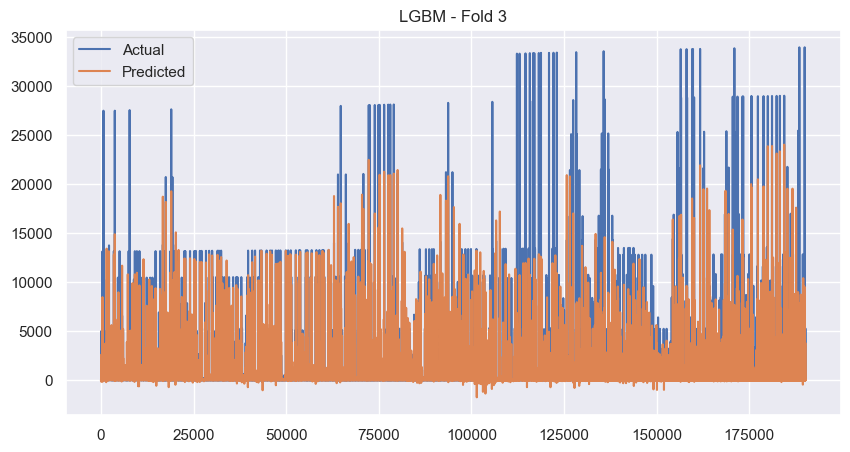

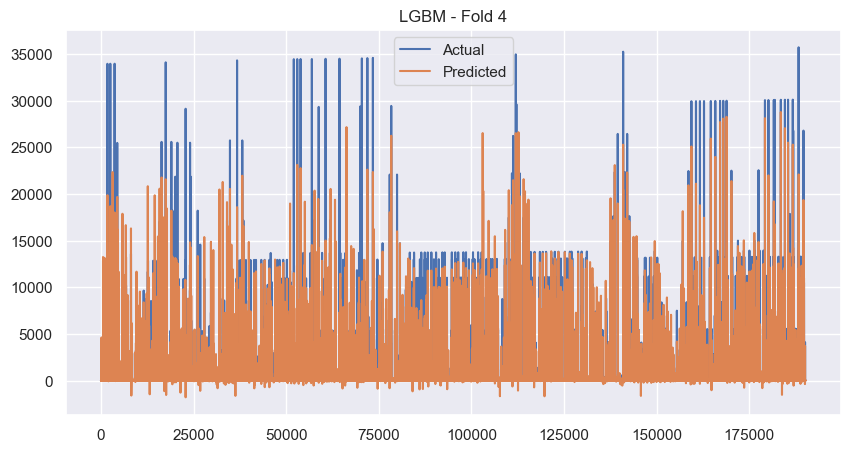

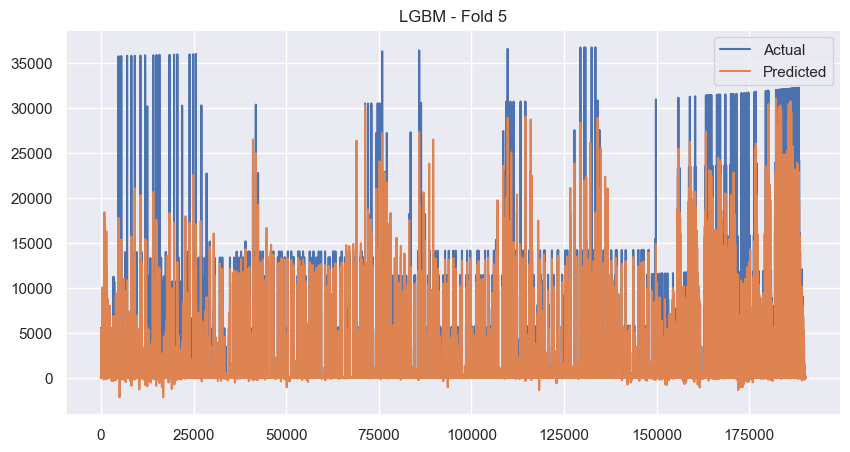

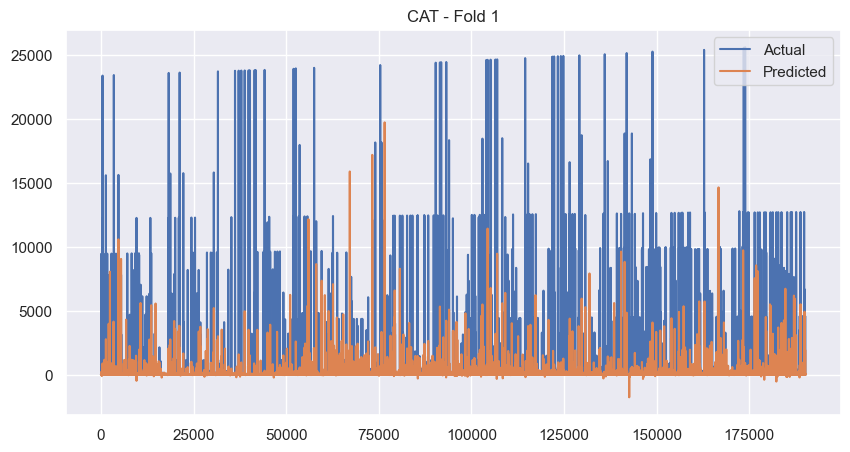

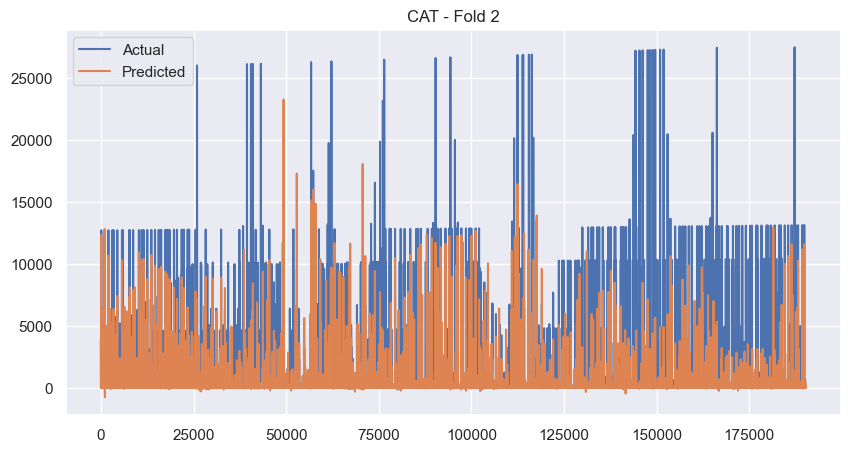

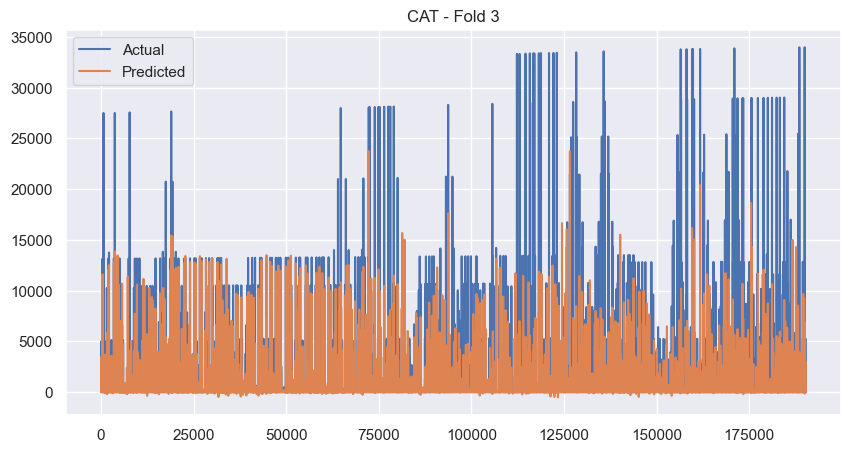

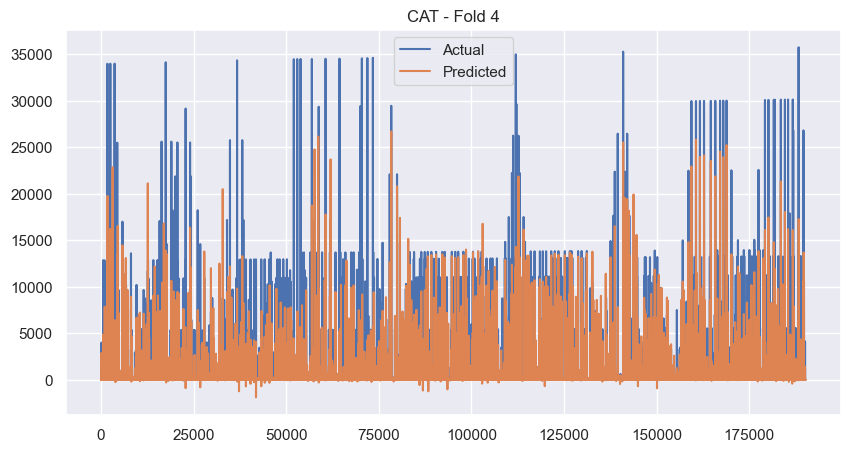

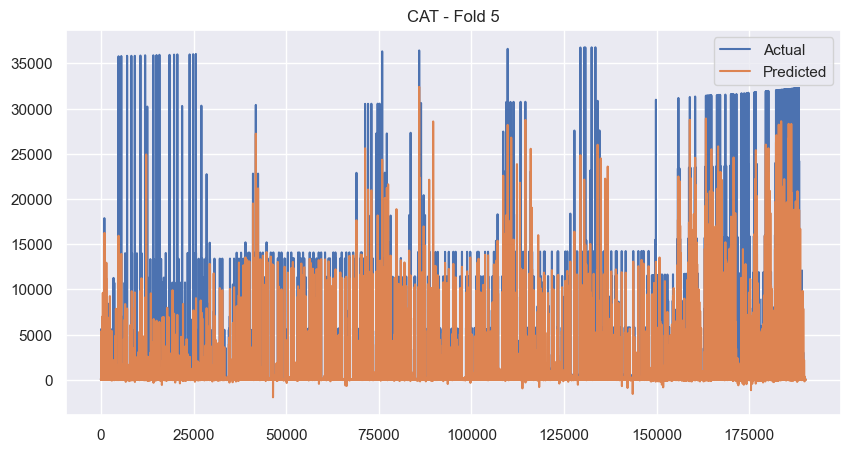

In [42]:
for name, df_model in {
    "RF": rf_predictions,
    "XGB": xgb_predictions,
    "LGBM": lgbm_predictions,
    "CAT": cat_predictions
}.items():

    for fold in sorted(df_model["fold"].unique()):
        
        subset = df_model[df_model["fold"] == fold]

        plt.figure(figsize=(10,5))
        plt.plot(subset["actual"].values, label="Actual")
        plt.plot(subset["predicted"].values, label="Predicted")

        plt.title(f"{name} - Fold {fold}")
        plt.legend()
        plt.show()

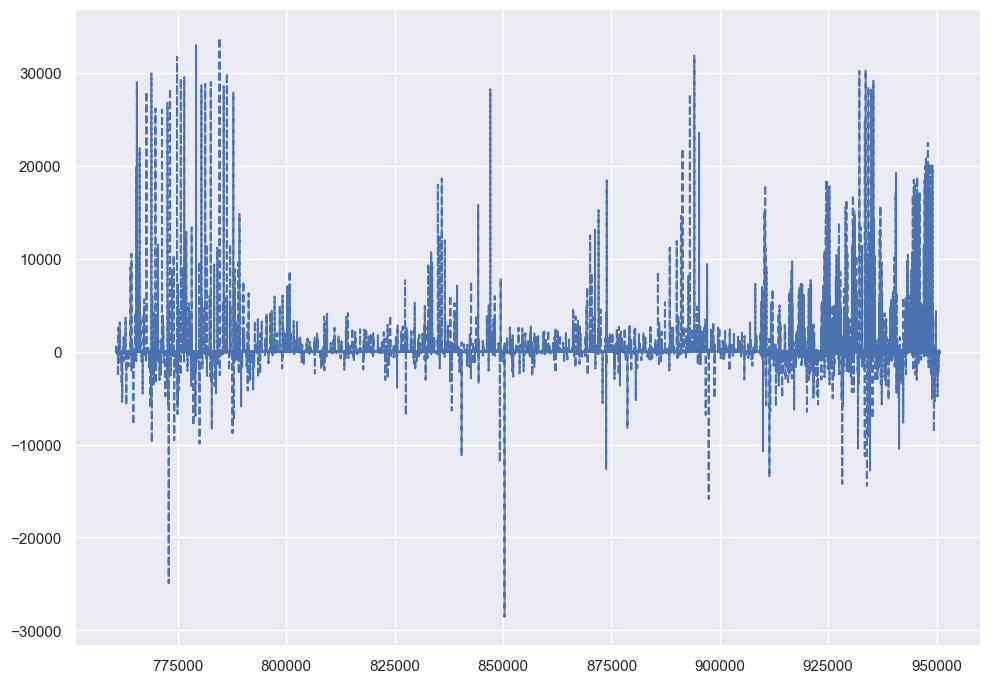

In [43]:
subset["residual"] = subset["actual"] - subset["predicted"]

plt.plot(subset["residual"], label="Residual", linestyle="--")

EXPLAINABILITY

Same model retrained as before

In [ ]:
import shap
explainer = shap.TreeExplainer(rf_last_model)
shap_values = explainer.shap_values(rf_last_test)

In [ ]:
shap.summary_plot(shap_values, rf_last_test)

In [ ]:
shap.summary_plot(shap_values, rf_last_test, plot_type="bar")